# Problem 2: Geospatial location of COVID19 confirmed cases
*20 points*

**This is intended for educational purposes and is not intended as a realistic analysis of the COVID-19 virus confirmed cases.**



## Problem 2a
*10 points*

Download the dataset, extract the data for mainland US locations, and plot the data for Erie County. Specifically:

- Execute the following cell to download the data with `wget`. 
- Extract the geographical data for mainland US locations, namely the location name (`Combined_Key`), latitude, and longitude from each row. The mainland US can be defined by (25 < latitude < 50) and (-130 < longitude < -70).
    - You are welcome to use whatever data structure you like (dict, numpy array, pandas dataframe, etc.).
    - Warning: some automated loaders like `np.genfromtxt` might not work, as some columns have "," characters inside quotation marks.
- Extract the number of confirmed cases vs. date for each location into another array.
- Plot the number of *new* confirmed cases vs. date for Erie County.
    - The CSV file contains the cumulative number of cases, so you have to compute the number of new cases per day).
    - If you convert the date strings to python `datetime.date` objects, matplotlib can automatically make a nice date-axis for you. 


In [8]:
! wget -nc https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv
! head -n 5 COVID-19/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv  | cut -c 1-300


File ‘time_series_covid19_confirmed_US.csv’ already there; not retrieving.

head: cannot open 'COVID-19/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv' for reading: No such file or directory


In [9]:
import csv
import numpy as np
import math
import copy
import matplotlib.pyplot as plt
import datetime

### Read data from CSV file into numpy array

In [10]:
'''
# Some starter code for using csv
import csv

data_path = 'COVID-19/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv'
# Initialize some storage
col_idx = {}
reader = csv.reader(open(data_path), delimiter=',')
for ir, r in enumerate(reader):
    if ir == 0: 
        # Process header, e.g., get indices of relevant columns
        # Ex: col_idx["lat"] = r.index("lat")
    else:
        # Extract values from row
        # Ex: lat = r[8]
    ir += 1
'''

'\n# Some starter code for using csv\nimport csv\n\ndata_path = \'COVID-19/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv\'\n# Initialize some storage\ncol_idx = {}\nreader = csv.reader(open(data_path), delimiter=\',\')\nfor ir, r in enumerate(reader):\n    if ir == 0: \n        # Process header, e.g., get indices of relevant columns\n        # Ex: col_idx["lat"] = r.index("lat")\n    else:\n        # Extract values from row\n        # Ex: lat = r[8]\n    ir += 1\n'

In [11]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import datetime

data_path = 'time_series_covid19_confirmed_US.csv'

col_idx  = {}
geo      = []
counts   = [] 
dates    = []

with open(data_path, newline='') as f:
    reader = csv.reader(f)
    for ir, r in enumerate(reader):
        if ir == 0:
            col_idx    = {name: i for i, name in enumerate(r)}
            date_start = col_idx['Combined_Key'] + 1
            dates = [datetime.datetime.strptime(d, '%m/%d/%y') for d in r[date_start:]]
        else:
            lat = float(r[col_idx['Lat']]   or 0)
            lon = float(r[col_idx['Long_']] or 0)
            if 25 < lat < 50 and -130 < lon < -70:
                geo.append({
                    'name': r[col_idx['Combined_Key']],
                    'lat':  lat,
                    'lon':  lon,
                })
                counts.append(np.array(r[date_start:], dtype=float))

counts = np.array(counts)
dates  = np.array(dates)

print(f"Mainland locations: {len(geo)}")
print(f"Date range: {dates[0].date()} → {dates[-1].date()}")

Mainland locations: 3105
Date range: 2020-01-22 → 2023-03-09


### Plot the number of new confirmed cases vs. day for Erie County

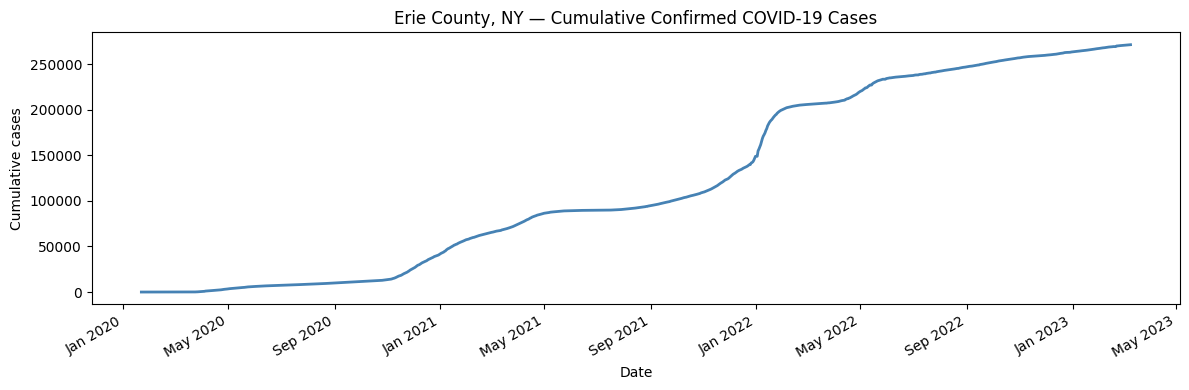

In [15]:
cumulative = counts[erie_idx]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, cumulative, color='steelblue', linewidth=2)
ax.set_title('Erie County, NY — Cumulative Confirmed COVID-19 Cases')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative cases')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Problem 2b: Voronoi diagram
*10 points*

Select locations with nonzero confirm cases on March 20, 2020. Make a Voronoi diagram with 10 cells of the geographical coordinates (lat, long) of these locations, i.e., treat the (lat, long) coordinates as if they were 2D Euclidean coordinates. You can adapt the `kmeans.ipynb` notebook, which has been copied to this folder. Specifically

- Assume there are 10 Voronoi cells.
- Initialize the centroids to 10 randomly chosen points from the dataset.
- Run $k$-means iterations to compute the centroids that minimize the $k$-means distance to the data points.
- For the final configuration, plot:
    - The centroids of the data in black circles.
    - The data points in each cell with a different color. 


In [ ]:
# Voronoi code goes here


Locations with nonzero cases on 2020-03-20: 891
Converged at iteration 44


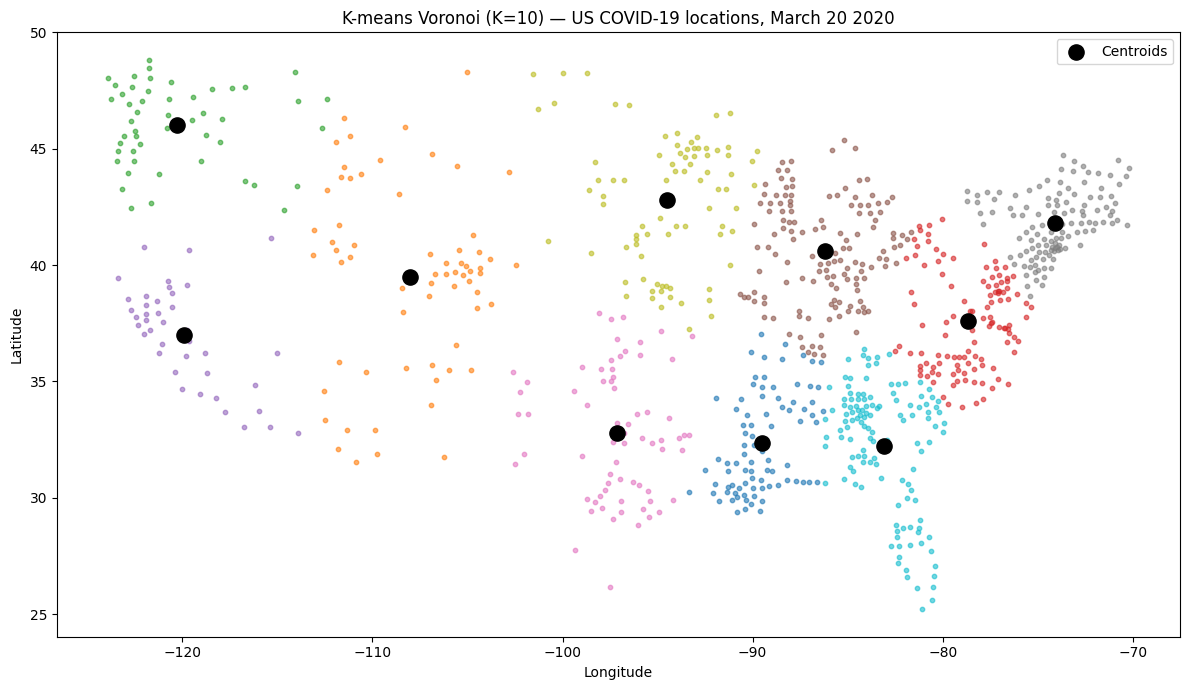

In [17]:

target_date = datetime.datetime(2020, 3, 20)
date_idx = np.where(dates == target_date)[0][0]

mask = counts[:, date_idx] > 0
geo_filtered = [g for g, m in zip(geo, mask) if m]
counts_filtered = counts[mask]

coords = np.array([[g['lat'], g['lon']] for g in geo_filtered])
print(f"Locations with nonzero cases on {target_date.date()}: {len(coords)}")

K = 10
np.random.seed(42)

rng_idx = np.random.choice(len(coords), K, replace=False)
centroids = coords[rng_idx].copy()

def assign_clusters(coords, centroids):
    diffs = coords[:, None, :] - centroids[None, :, :]   # (N, K, 2)
    dists = np.linalg.norm(diffs, axis=2)                 # (N, K)
    return np.argmin(dists, axis=1)                       # (N,)

for iteration in range(200):
    labels = assign_clusters(coords, centroids)
    new_centroids = np.array([
        coords[labels == k].mean(axis=0) if np.any(labels == k) else centroids[k]
        for k in range(K)
    ])
    if np.allclose(new_centroids, centroids):
        print(f"Converged at iteration {iteration}")
        break
    centroids = new_centroids

labels = assign_clusters(coords, centroids)

colors = plt.cm.tab10(np.arange(K))

fig, ax = plt.subplots(figsize=(12, 7))

for k in range(K):
    pts = coords[labels == k]
    ax.scatter(pts[:, 1], pts[:, 0], s=10, color=colors[k], alpha=0.6)

ax.scatter(centroids[:, 1], centroids[:, 0],
           s=120, c='black', marker='o', zorder=5, label='Centroids')

ax.set_title('K-means Voronoi (K=10) — US COVID-19 locations, March 20 2020')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()